In [21]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [22]:
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

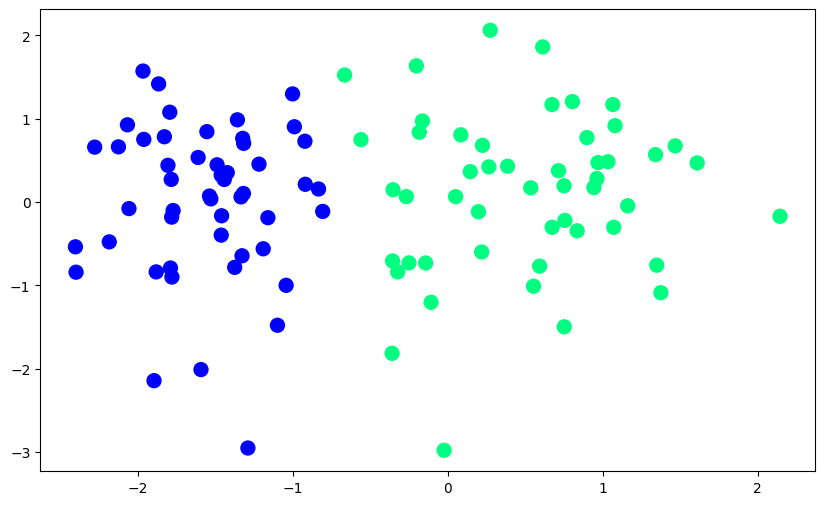

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [24]:
def perceptron(X, y, epochs=30, delay=0.35):
    X_bias = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X_bias.shape[1])
    lr = 0.01

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="winter", s=100)
    ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax.set_ylim(-3, 2)

    line, = ax.plot([], [], color="red", linewidth=3)
    x_line = np.linspace(*ax.get_xlim(), 100)

    def update_boundary():
        if abs(weights[2]) > 1e-12:
            y_line = -(weights[0] + weights[1] * x_line) / weights[2]
            line.set_data(x_line, y_line)
        elif abs(weights[1]) > 1e-12:
            x_boundary = -weights[0] / weights[1]
            line.set_data([x_boundary, x_boundary], ax.get_ylim())

    update_boundary()
    display(fig)
    plt.pause(delay)

    update_count = 0
    for epoch in range(epochs):
        mistakes = 0
        for j in np.random.permutation(len(y)):
            y_hat = step(np.dot(X_bias[j], weights))
            if y_hat != y[j]:
                weights += lr * (y[j] - y_hat) * X_bias[j]
                mistakes += 1
                update_count += 1
                update_boundary()
                ax.set_title(f"Epoch {epoch + 1}/{epochs} | weight update {update_count}")
                clear_output(wait=True)
                display(fig)
                plt.pause(delay)

        if mistakes == 0:
            ax.set_title(f"Converged after epoch {epoch + 1}")
            clear_output(wait=True)
            display(fig)
            break

    plt.close(fig)
    return weights[0], weights[1:]

In [25]:
def step(z):
    return 1 if z>0 else 0

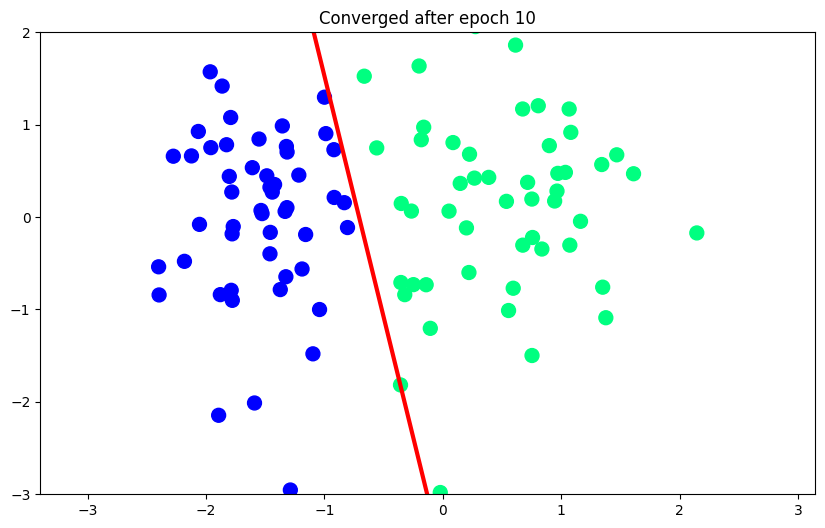

In [26]:
intercept_,coef_ = perceptron(X,y)

In [27]:
print(coef_)
print(intercept_)

[1.30021444 0.24925586]
0.9199999999999999


In [28]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [29]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

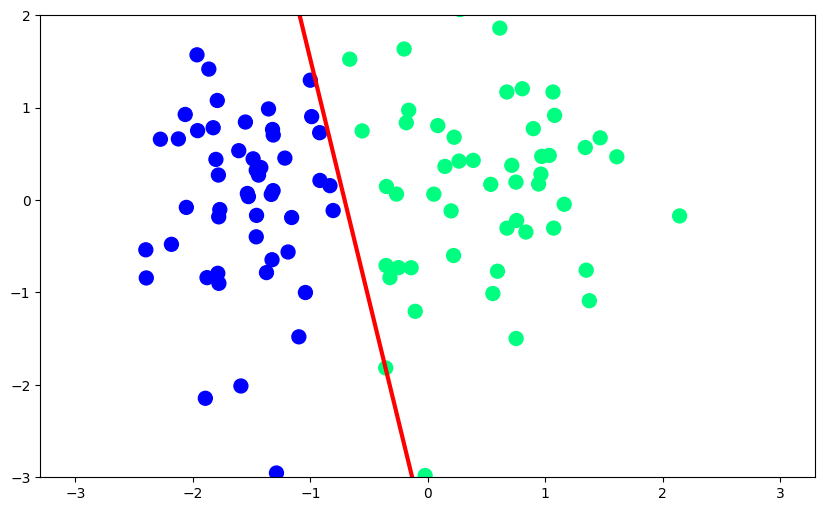

In [30]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)